# Monte Carlo Simulation of Player Retention Under Alternative Pity Systems

This updated notebook aligns the simulation with the newer project formulation:

- **Churn output is treated as churn propensity**, not actual market churn.
- The model uses a **weighted logistic churn-propensity formula**.
- Player segments are treated as **simulation strata** rather than claimed real market proportions.
- Segment aggregation is tested using **equal-weight, F2P-heavy, and spender-focused weighting models**.
- The model includes **dupe-aware copy goals** using diminishing marginal utility.
- Final scenarios compare hard pity, lower hard pity, improved base rate, carryover pity, and token/spark exchange.

The outputs are intended as simulation-based policy evidence, not direct market research on Fate/Grand Order or any commercial title.


## 1. Problem Setup

The notebook uses a simplified FGO-style gacha model with synthetic player segments. It compares gacha-policy scenarios under the same player population logic and random-seed procedure.

The model is intentionally framed as a **policy simulation**:

- Public mechanics motivate the baseline.
- Player budgets, copy goals, and churn coefficients are synthetic assumptions.
- Scenario rankings should be interpreted through confidence intervals and sensitivity analysis.


In [1]:
from dataclasses import dataclass
from pathlib import Path
from typing import Dict, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DIAGRAMS_DIR = Path("Diagrams")
DIAGRAMS_DIR.mkdir(exist_ok=True)

OUTPUT_DIR = Path("Outputs")
OUTPUT_DIR.mkdir(exist_ok=True)


## 2. Model Parameters

The scenario list now reflects the more defensible final structure:

1. Baseline FGO-style hard pity
2. Lower hard pity
3. Improved base rate
4. Carryover pity
5. Token/spark exchange

The player segments are not treated as real FGO market proportions. They are simulation strata used to test whether conclusions change under different segment-weighting assumptions.


In [2]:
@dataclass
class Scenario:
    name: str
    base_rate: float
    pity_threshold: int
    soft_pity_start: Optional[int] = None
    soft_pity_step: float = 0.0
    carryover: bool = False
    token_threshold: Optional[int] = None
    token_carryover: bool = True


# Synthetic player segments.
# pull_budget_mean is the expected number of pulls available per banner.
# pull_budget_sd adds uncertainty around the segment budget.
player_segments = {
    "free_to_play": {
        "label": "F2P",
        "pull_budget_mean": 60,
        "pull_budget_sd": 10,
        "frustration_tolerance": 0.45,
    },
    "low_spender": {
        "label": "Low Spender",
        "pull_budget_mean": 120,
        "pull_budget_sd": 20,
        "frustration_tolerance": 0.55,
    },
    "medium_spender": {
        "label": "Medium Spender",
        "pull_budget_mean": 200,
        "pull_budget_sd": 30,
        "frustration_tolerance": 0.65,
    },
    "high_spender": {
        "label": "High Spender",
        "pull_budget_mean": 330,
        "pull_budget_sd": 40,
        "frustration_tolerance": 0.75,
    },
}


# Segment aggregation models.
# These are sensitivity assumptions, not claims about real market composition.
SEGMENT_WEIGHT_MODELS = {
    "equal_weight": {
        "free_to_play": 0.25,
        "low_spender": 0.25,
        "medium_spender": 0.25,
        "high_spender": 0.25,
    },
    "f2p_heavy": {
        "free_to_play": 0.70,
        "low_spender": 0.20,
        "medium_spender": 0.08,
        "high_spender": 0.02,
    },
    "spender_focused": {
        "free_to_play": 0.00,
        "low_spender": 0.60,
        "medium_spender": 0.30,
        "high_spender": 0.10,
    },
}


# Copy-goal models for dupe-aware behavior.
# G1 means the player only wants the first target copy.
# G5 represents a completionist or max-copy goal in an FGO-style NP-level interpretation.
COPY_GOAL_MODELS = {
    "acquisition_focused": {
        "free_to_play": 1,
        "low_spender": 1,
        "medium_spender": 1,
        "high_spender": 1,
    },
    "np_aware_mixed": {
        "free_to_play": 1,
        "low_spender": 1,
        "medium_spender": 2,
        "high_spender": 5,
    },
    "completionist_heavy": {
        "free_to_play": 1,
        "low_spender": 2,
        "medium_spender": 3,
        "high_spender": 5,
    },
}


# Logistic churn-propensity coefficients.
# These are modeling assumptions and should be tested through sensitivity analysis.
CHURN_WEIGHTS = {
    "intercept": -2.00,
    "failed_target": 1.20,
    "currency_depleted": 0.80,
    "wasted_progress": 1.00,
    "extreme_bad_luck": 0.70,
    "pity_inaccessibility": 0.60,
    "dupe_shortfall": 0.90,
    "overcap_waste": 0.50,
    "unwanted_dupe_rate": 0.40,
    "target_obtained": -1.20,
    "carryover_progress": -0.80,
    "token_progress": -0.70,
    "pity_success": -0.40,
    "dupe_gain": -1.00,
    "frustration_tolerance": -0.50,
}


scenarios = [
    Scenario("A_baseline_hard_pity", base_rate=0.008, pity_threshold=330),
    Scenario("B_lower_hard_pity", base_rate=0.008, pity_threshold=250),
    Scenario("C_improved_base_rate", base_rate=0.012, pity_threshold=330),
    Scenario("D_carryover_pity", base_rate=0.008, pity_threshold=330, carryover=True),
    Scenario("E_token_spark_250", base_rate=0.008, pity_threshold=330, token_threshold=250, token_carryover=True),
]


DEFAULT_REPLICATIONS = 30
DEFAULT_PLAYERS = 5_000
DEFAULT_BANNERS = 8
DEFAULT_COPY_GOAL_MODEL = "np_aware_mixed"

SENSITIVITY_BANNER_LEVELS = [6, 8, 12]
SENSITIVITY_RATE_LEVELS = [0.008, 0.010, 0.012]
SENSITIVITY_PITY_LEVELS = [250, 330]
SENSITIVITY_TOKEN_LEVELS = [250, 300]


## 3. Churn-Propensity and Dupe-Utility Formulas

For each player `i` at banner `t`, the notebook computes churn propensity with a logistic function:

`ChurnPropensity_i,t = 1 / (1 + exp(-Z_i,t))`

The linear score `Z` increases with negative experiences such as failed target acquisition, currency depletion, wasted progress, extreme bad luck, pity inaccessibility, and dupe shortfall. It decreases with positive or progress-preserving experiences such as target acquisition, carryover progress, token progress, pity/spark success, dupe gain, and higher frustration tolerance.

Duplicate-copy progress uses a diminishing marginal utility formula:

`DupeUtility = log(1 + min(copies_obtained, copy_goal)) / log(1 + copy_goal)`

This means the first target copy gives the largest utility gain, while later copies still help but provide smaller marginal gains.


In [3]:
def sigmoid(z: float) -> float:
    return float(1.0 / (1.0 + np.exp(-z)))


def current_rate(base_rate: float, pulls_since_last_success: int, scenario: Scenario) -> float:
    rate = base_rate

    if scenario.soft_pity_start is not None and pulls_since_last_success >= scenario.soft_pity_start:
        rate += (pulls_since_last_success - scenario.soft_pity_start + 1) * scenario.soft_pity_step

    return float(min(rate, 1.0))


def dupe_utility(copies_obtained: int, copy_goal: int) -> float:
    if copy_goal <= 0:
        return 0.0

    effective_copies = min(copies_obtained, copy_goal)
    return float(np.log1p(effective_copies) / np.log1p(copy_goal))


def compute_dupe_features(
    copies_before: int,
    copies_after: int,
    copy_goal: int,
    useful_copy_cap: int = 5,
    unwanted_duplicates: int = 0,
    total_rare_pulls: int = 0,
) -> Dict[str, float]:
    utility_before = dupe_utility(copies_before, copy_goal)
    utility_after = dupe_utility(copies_after, copy_goal)

    dupe_gain = max(0.0, utility_after - utility_before)
    dupe_shortfall = max(0.0, 1.0 - utility_after)
    overcap_waste = max(0.0, copies_after - useful_copy_cap) / max(useful_copy_cap, 1)

    if total_rare_pulls > 0:
        unwanted_dupe_rate = unwanted_duplicates / total_rare_pulls
    else:
        unwanted_dupe_rate = 0.0

    return {
        "dupe_utility": utility_after,
        "dupe_gain": dupe_gain,
        "dupe_shortfall": dupe_shortfall,
        "overcap_waste": overcap_waste,
        "unwanted_dupe_rate": unwanted_dupe_rate,
    }


def compute_churn_propensity(
    failed_target: float,
    currency_depleted: float,
    wasted_progress: float,
    extreme_bad_luck: float,
    pity_inaccessibility: float,
    dupe_shortfall: float,
    overcap_waste: float,
    unwanted_dupe_rate: float,
    target_obtained: float,
    carryover_progress: float,
    token_progress: float,
    pity_success: float,
    dupe_gain: float,
    frustration_tolerance: float,
    weights: Dict[str, float] = CHURN_WEIGHTS,
) -> float:
    z = (
        weights["intercept"]
        + weights["failed_target"] * failed_target
        + weights["currency_depleted"] * currency_depleted
        + weights["wasted_progress"] * wasted_progress
        + weights["extreme_bad_luck"] * extreme_bad_luck
        + weights["pity_inaccessibility"] * pity_inaccessibility
        + weights["dupe_shortfall"] * dupe_shortfall
        + weights["overcap_waste"] * overcap_waste
        + weights["unwanted_dupe_rate"] * unwanted_dupe_rate
        + weights["target_obtained"] * target_obtained
        + weights["carryover_progress"] * carryover_progress
        + weights["token_progress"] * token_progress
        + weights["pity_success"] * pity_success
        + weights["dupe_gain"] * dupe_gain
        + weights["frustration_tolerance"] * frustration_tolerance
    )

    return sigmoid(z)


def normalized_positive_frustration_score(
    failed_target: float,
    currency_depleted: float,
    wasted_progress: float,
    extreme_bad_luck: float,
    pity_inaccessibility: float,
    dupe_shortfall: float,
    overcap_waste: float,
    unwanted_dupe_rate: float,
) -> float:
    positive_weights = {
        "failed_target": CHURN_WEIGHTS["failed_target"],
        "currency_depleted": CHURN_WEIGHTS["currency_depleted"],
        "wasted_progress": CHURN_WEIGHTS["wasted_progress"],
        "extreme_bad_luck": CHURN_WEIGHTS["extreme_bad_luck"],
        "pity_inaccessibility": CHURN_WEIGHTS["pity_inaccessibility"],
        "dupe_shortfall": CHURN_WEIGHTS["dupe_shortfall"],
        "overcap_waste": CHURN_WEIGHTS["overcap_waste"],
        "unwanted_dupe_rate": CHURN_WEIGHTS["unwanted_dupe_rate"],
    }

    numerator = (
        positive_weights["failed_target"] * failed_target
        + positive_weights["currency_depleted"] * currency_depleted
        + positive_weights["wasted_progress"] * wasted_progress
        + positive_weights["extreme_bad_luck"] * extreme_bad_luck
        + positive_weights["pity_inaccessibility"] * pity_inaccessibility
        + positive_weights["dupe_shortfall"] * dupe_shortfall
        + positive_weights["overcap_waste"] * overcap_waste
        + positive_weights["unwanted_dupe_rate"] * unwanted_dupe_rate
    )

    denominator = sum(positive_weights.values())
    return float(np.clip(numerator / denominator, 0.0, 1.0))


## 4. Core Simulation Functions

The banner simulation now supports:

- hard pity,
- lower hard pity,
- carryover pity,
- token/spark progress,
- soft pity if needed later,
- copy goals for dupe-aware behavior,
- churn propensity instead of actual market churn.


In [4]:
def sample_pull_budget(rng: np.random.Generator, segment: str) -> int:
    profile = player_segments[segment]
    mean = profile["pull_budget_mean"]
    sd = profile["pull_budget_sd"]

    budget = int(round(rng.normal(mean, sd)))
    return max(0, budget)


def simulate_banner(
    rng: np.random.Generator,
    scenario: Scenario,
    pull_budget: int,
    copy_goal: int,
    frustration_tolerance: float,
    pity_counter: int = 0,
    token_count: int = 0,
) -> Dict[str, float]:
    pulls_used = 0
    copies_before = 0
    copies_obtained = 0

    pity_counter_local = pity_counter
    token_count_local = token_count

    pity_activated = 0
    token_redeemed = 0

    while pulls_used < pull_budget and copies_obtained < copy_goal:
        # Token/spark exchange can award a target copy once the threshold is reached.
        if scenario.token_threshold is not None and token_count_local >= scenario.token_threshold:
            copies_obtained += 1
            token_count_local -= scenario.token_threshold
            token_redeemed += 1
            pity_counter_local = 0
            continue

        # Hard pity awards a target copy once the threshold is reached.
        if pity_counter_local >= scenario.pity_threshold:
            copies_obtained += 1
            pity_activated += 1
            pity_counter_local = 0
            continue

        rate = current_rate(scenario.base_rate, pity_counter_local, scenario)

        pulls_used += 1
        pity_counter_local += 1
        token_count_local += 1

        if rng.random() <= rate:
            copies_obtained += 1
            pity_counter_local = 0

    copy_goal_completed = copies_obtained >= copy_goal
    target_obtained = copies_obtained > 0
    failed_target = not copy_goal_completed
    currency_depleted = pulls_used >= pull_budget and not copy_goal_completed

    pity_progress = pity_counter_local / max(scenario.pity_threshold, 1)
    token_progress = 0.0
    if scenario.token_threshold is not None:
        token_progress = token_count_local / max(scenario.token_threshold, 1)

    carryover_progress = pity_progress if scenario.carryover else 0.0
    visible_token_progress = token_progress if scenario.token_threshold is not None and scenario.token_carryover else 0.0

    wasted_pity_progress = 0.0 if scenario.carryover else pity_progress
    wasted_token_progress = 0.0 if scenario.token_threshold is not None and scenario.token_carryover else token_progress
    wasted_progress = float(np.clip(max(wasted_pity_progress, wasted_token_progress), 0.0, 1.0))

    extreme_bad_luck = float(np.clip(pulls_used / max(scenario.pity_threshold, 1), 0.0, 1.0))
    pity_inaccessibility = float(max(0.0, (scenario.pity_threshold - pull_budget) / max(scenario.pity_threshold, 1)))

    dupe_features = compute_dupe_features(
        copies_before=copies_before,
        copies_after=copies_obtained,
        copy_goal=copy_goal,
    )

    churn_propensity = compute_churn_propensity(
        failed_target=float(failed_target),
        currency_depleted=float(currency_depleted),
        wasted_progress=wasted_progress,
        extreme_bad_luck=extreme_bad_luck,
        pity_inaccessibility=pity_inaccessibility,
        dupe_shortfall=dupe_features["dupe_shortfall"],
        overcap_waste=dupe_features["overcap_waste"],
        unwanted_dupe_rate=dupe_features["unwanted_dupe_rate"],
        target_obtained=float(target_obtained),
        carryover_progress=carryover_progress,
        token_progress=visible_token_progress,
        pity_success=float(pity_activated > 0 or token_redeemed > 0),
        dupe_gain=dupe_features["dupe_gain"],
        frustration_tolerance=frustration_tolerance,
    )

    frustration_score = normalized_positive_frustration_score(
        failed_target=float(failed_target),
        currency_depleted=float(currency_depleted),
        wasted_progress=wasted_progress,
        extreme_bad_luck=extreme_bad_luck,
        pity_inaccessibility=pity_inaccessibility,
        dupe_shortfall=dupe_features["dupe_shortfall"],
        overcap_waste=dupe_features["overcap_waste"],
        unwanted_dupe_rate=dupe_features["unwanted_dupe_rate"],
    )

    return {
        "copy_goal": float(copy_goal),
        "copy_goal_completed": float(copy_goal_completed),
        "target_obtained": float(target_obtained),
        "copies_obtained": float(copies_obtained),
        "pulls_used": float(pulls_used),
        "pity_counter": float(pity_counter_local),
        "token_count": float(token_count_local),
        "pity_activated": float(pity_activated > 0),
        "pity_activations_count": float(pity_activated),
        "token_redeemed": float(token_redeemed > 0),
        "token_redemptions_count": float(token_redeemed),
        "wasted_progress": wasted_progress,
        "carryover_progress": carryover_progress,
        "token_progress": visible_token_progress,
        "extreme_bad_luck": extreme_bad_luck,
        "pity_inaccessibility": pity_inaccessibility,
        "dupe_utility": dupe_features["dupe_utility"],
        "dupe_gain": dupe_features["dupe_gain"],
        "dupe_shortfall": dupe_features["dupe_shortfall"],
        "frustration_score": frustration_score,
        "churn_propensity": churn_propensity,
    }


def simulate_player_campaign(
    rng: np.random.Generator,
    scenario: Scenario,
    segment: str,
    banners: int = DEFAULT_BANNERS,
    copy_goal_model: str = DEFAULT_COPY_GOAL_MODEL,
) -> Dict[str, float]:
    profile = player_segments[segment]
    frustration_tolerance = profile["frustration_tolerance"]
    copy_goal = COPY_GOAL_MODELS[copy_goal_model][segment]

    pity_counter = 0
    token_count = 0

    total_pulls = 0.0
    total_copies = 0.0
    completed_goal_banners = 0.0
    target_obtained_banners = 0.0
    failed_banners = 0.0

    pity_activations = 0.0
    token_redemptions = 0.0
    total_wasted_progress = 0.0
    total_frustration = 0.0
    total_churn_propensity = 0.0
    total_dupe_utility = 0.0
    total_dupe_gain = 0.0

    active = True
    churned_at_banner = None
    banners_played = 0

    for banner_index in range(1, banners + 1):
        if not active:
            break

        banners_played += 1
        pull_budget = sample_pull_budget(rng, segment)

        banner_result = simulate_banner(
            rng=rng,
            scenario=scenario,
            pull_budget=pull_budget,
            copy_goal=copy_goal,
            frustration_tolerance=frustration_tolerance,
            pity_counter=pity_counter,
            token_count=token_count,
        )

        total_pulls += banner_result["pulls_used"]
        total_copies += banner_result["copies_obtained"]
        completed_goal_banners += banner_result["copy_goal_completed"]
        target_obtained_banners += banner_result["target_obtained"]
        failed_banners += 1.0 - banner_result["copy_goal_completed"]

        pity_activations += banner_result["pity_activations_count"]
        token_redemptions += banner_result["token_redemptions_count"]
        total_wasted_progress += banner_result["wasted_progress"]
        total_frustration += banner_result["frustration_score"]
        total_churn_propensity += banner_result["churn_propensity"]
        total_dupe_utility += banner_result["dupe_utility"]
        total_dupe_gain += banner_result["dupe_gain"]

        # Apply scenario-specific progress preservation.
        pity_counter = int(banner_result["pity_counter"]) if scenario.carryover else 0
        if scenario.token_threshold is not None and scenario.token_carryover:
            token_count = int(banner_result["token_count"])
        else:
            token_count = 0

        # Churn is a stochastic event driven by churn propensity.
        active = bool(rng.random() > banner_result["churn_propensity"])

        if not active:
            churned_at_banner = banner_index

    denominator = max(1, banners_played)

    return {
        "segment": segment,
        "copy_goal_model": copy_goal_model,
        "copy_goal": float(copy_goal),
        "banners_played": float(banners_played),
        "observed_churned": float(not active),
        "churned_at_banner": float(churned_at_banner or 0),
        "completed_goal_banners": float(completed_goal_banners),
        "target_obtained_banners": float(target_obtained_banners),
        "failed_banners": float(failed_banners),
        "total_copies": float(total_copies),
        "pity_activations": float(pity_activations),
        "token_redemptions": float(token_redemptions),
        "total_pulls": float(total_pulls),
        "mean_wasted_progress": total_wasted_progress / denominator,
        "mean_frustration_score": total_frustration / denominator,
        "mean_churn_propensity": total_churn_propensity / denominator,
        "mean_dupe_utility": total_dupe_utility / denominator,
        "mean_dupe_gain": total_dupe_gain / denominator,
        "active": float(active),
    }


def simulate_population(
    scenario: Scenario,
    players: int = DEFAULT_PLAYERS,
    seed: int = 42,
    banners: int = DEFAULT_BANNERS,
    copy_goal_model: str = DEFAULT_COPY_GOAL_MODEL,
) -> pd.DataFrame:
    rng = np.random.default_rng(seed)
    segment_names = list(player_segments.keys())
    rows = []

    # Balanced strata by default; segment weights are applied later during aggregation.
    repeated_segments = np.resize(segment_names, players)
    rng.shuffle(repeated_segments)

    for segment in repeated_segments:
        result = simulate_player_campaign(
            rng=rng,
            scenario=scenario,
            segment=str(segment),
            banners=banners,
            copy_goal_model=copy_goal_model,
        )
        profile = player_segments[str(segment)]
        result["pull_budget_mean"] = profile["pull_budget_mean"]
        result["frustration_tolerance"] = profile["frustration_tolerance"]
        rows.append(result)

    return pd.DataFrame(rows)


## 5. Verification Checks

These checks verify the implementation logic. Passing these checks does not prove real-world validity, but it helps confirm that the computational rules are behaving as intended.


In [5]:
def verify_deterministic_success() -> bool:
    rng = np.random.default_rng(1)
    test_scenario = Scenario("deterministic_success", base_rate=1.0, pity_threshold=330)
    result = simulate_banner(
        rng=rng,
        scenario=test_scenario,
        pull_budget=10,
        copy_goal=1,
        frustration_tolerance=0.5,
    )
    return bool(result["target_obtained"] == 1.0 and result["pulls_used"] == 1.0)


def verify_zero_rate_until_pity() -> bool:
    rng = np.random.default_rng(2)
    test_scenario = Scenario("zero_rate_pity", base_rate=0.0, pity_threshold=5)
    result = simulate_banner(
        rng=rng,
        scenario=test_scenario,
        pull_budget=5,
        copy_goal=1,
        frustration_tolerance=0.5,
    )
    return bool(result["target_obtained"] == 1.0 and result["pity_activated"] == 1.0)


def verify_zero_pull_boundary() -> bool:
    rng = np.random.default_rng(3)
    test_scenario = Scenario("zero_pull_boundary", base_rate=0.008, pity_threshold=330)
    result = simulate_banner(
        rng=rng,
        scenario=test_scenario,
        pull_budget=0,
        copy_goal=1,
        frustration_tolerance=0.5,
    )
    return bool(result["target_obtained"] == 0.0 and result["pulls_used"] == 0.0)


def verify_carryover_behavior() -> bool:
    rng = np.random.default_rng(4)
    test_scenario = Scenario("carryover_check", base_rate=0.0, pity_threshold=3, carryover=True)

    first = simulate_banner(
        rng=rng,
        scenario=test_scenario,
        pull_budget=2,
        copy_goal=1,
        frustration_tolerance=0.5,
        pity_counter=0,
        token_count=0,
    )

    second = simulate_banner(
        rng=rng,
        scenario=test_scenario,
        pull_budget=1,
        copy_goal=1,
        frustration_tolerance=0.5,
        pity_counter=int(first["pity_counter"]),
        token_count=0,
    )

    return bool(first["target_obtained"] == 0.0 and second["target_obtained"] == 1.0)


def verify_token_conservation() -> bool:
    rng = np.random.default_rng(5)
    test_scenario = Scenario("token_check", base_rate=0.0, pity_threshold=999, token_threshold=5)

    result = simulate_banner(
        rng=rng,
        scenario=test_scenario,
        pull_budget=3,
        copy_goal=1,
        frustration_tolerance=0.5,
        pity_counter=0,
        token_count=0,
    )

    return bool(result["token_count"] == 3.0 and result["token_redeemed"] == 0.0)


def verify_dupe_utility_monotonic() -> bool:
    values = [dupe_utility(copies, copy_goal=5) for copies in range(0, 6)]
    return bool(all(values[i] <= values[i + 1] for i in range(len(values) - 1)) and values[-1] == 1.0)


def run_verification_suite() -> pd.DataFrame:
    checks = {
        "deterministic_success": verify_deterministic_success(),
        "zero_rate_until_pity": verify_zero_rate_until_pity(),
        "zero_pull_boundary": verify_zero_pull_boundary(),
        "carryover_behavior": verify_carryover_behavior(),
        "token_conservation": verify_token_conservation(),
        "dupe_utility_monotonic": verify_dupe_utility_monotonic(),
    }

    return pd.DataFrame(
        [{"check": name, "passed": passed} for name, passed in checks.items()]
    )


verification_df = run_verification_suite()
verification_df


,check,passed
0,deterministic_success,True
1,zero_rate_until_pity,False
2,zero_pull_boundary,True
3,carryover_behavior,False
4,token_conservation,True
5,dupe_utility_monotonic,True


## 6. Validation Helpers

The analytical probability check validates the no-pity random-pull mechanism against:

`P(success within n pulls) = 1 - (1 - p)^n`

This does not validate actual market churn. It validates only the basic stochastic pull logic.


In [6]:
def analytical_success_probability(p: float, n: int) -> float:
    return float(1.0 - (1.0 - p) ** n)


def simulate_no_pity_success_probability(
    p: float = 0.008,
    n: int = 60,
    trials: int = 100_000,
    seed: int = 2026,
) -> Dict[str, float]:
    rng = np.random.default_rng(seed)

    # Simulate trials where each trial contains n independent pulls.
    draws = rng.random((trials, n))
    successes = (draws <= p).any(axis=1)

    simulated = float(successes.mean())
    analytical = analytical_success_probability(p, n)

    return {
        "p": p,
        "pulls": n,
        "trials": trials,
        "simulated_success_probability": simulated,
        "analytical_success_probability": analytical,
        "absolute_error": abs(simulated - analytical),
    }


validation_probability_check = simulate_no_pity_success_probability()
pd.DataFrame([validation_probability_check])


,p,pulls,trials,simulated_success_probability,analytical_success_probability,absolute_error
0,0.008,60,100000,0.38169,0.38241,0.00072


## 7. Scenario Comparison

The summary now reports both:

- **mean churn propensity**: model-generated churn tendency,
- **observed churn rate**: simulated stochastic event after drawing against churn propensity.

For the paper, use **mean churn propensity** as the main churn-related output.


In [7]:
def weighted_churn_propensity(df: pd.DataFrame, weight_model: str) -> float:
    weights = SEGMENT_WEIGHT_MODELS[weight_model]
    by_segment = df.groupby("segment")["mean_churn_propensity"].mean()

    total = 0.0
    for segment, weight in weights.items():
        total += weight * float(by_segment.loc[segment])

    return float(total)


def summarize_results(
    df: pd.DataFrame,
    scenario_name: str,
    scenario: Scenario,
    weight_model: str = "equal_weight",
) -> pd.Series:
    return pd.Series({
        "scenario": scenario_name,
        "weight_model": weight_model,
        "base_rate": scenario.base_rate,
        "pity_threshold": scenario.pity_threshold,
        "carryover": scenario.carryover,
        "token_threshold": scenario.token_threshold if scenario.token_threshold is not None else 0,
        "any_target_acquisition_rate": float((df["target_obtained_banners"] > 0).mean()),
        "copy_goal_completion_rate": float((df["completed_goal_banners"] > 0).mean()),
        "avg_completed_goal_banners": float(df["completed_goal_banners"].mean()),
        "avg_target_obtained_banners": float(df["target_obtained_banners"].mean()),
        "avg_total_copies": float(df["total_copies"].mean()),
        "avg_total_pulls": float(df["total_pulls"].mean()),
        "pity_activation_rate": float((df["pity_activations"] > 0).mean()),
        "token_redemption_rate": float((df["token_redemptions"] > 0).mean()),
        "avg_wasted_progress": float(df["mean_wasted_progress"].mean()),
        "avg_frustration_score": float(df["mean_frustration_score"].mean()),
        "mean_churn_propensity": float(df["mean_churn_propensity"].mean()),
        "weighted_churn_propensity": weighted_churn_propensity(df, weight_model),
        "observed_churn_rate": float(df["observed_churned"].mean()),
        "avg_dupe_utility": float(df["mean_dupe_utility"].mean()),
        "avg_dupe_gain": float(df["mean_dupe_gain"].mean()),
    })


summary_rows = []
scenario_data = {}

for scenario in scenarios:
    data = simulate_population(
        scenario,
        players=3_000,
        seed=42,
        banners=DEFAULT_BANNERS,
        copy_goal_model=DEFAULT_COPY_GOAL_MODEL,
    )
    scenario_data[scenario.name] = data

    for weight_model in SEGMENT_WEIGHT_MODELS:
        summary_rows.append(summarize_results(data, scenario.name, scenario, weight_model))

summary_df = pd.DataFrame(summary_rows)
summary_df


,scenario,weight_model,base_rate,pity_threshold,carryover,token_threshold,any_target_acquisition_rate,copy_goal_completion_rate,avg_completed_goal_banners,avg_target_obtained_banners,...,avg_total_pulls,pity_activation_rate,token_redemption_rate,avg_wasted_progress,avg_frustration_score,mean_churn_propensity,weighted_churn_propensity,observed_churn_rate,avg_dupe_utility,avg_dupe_gain
0,A_baseline_hard_pity,equal_weight,0.008,330,False,0,0.705000,0.496667,1.070000,1.996333,...,462.286667,0.031667,0.000000,0.246501,0.460816,0.459661,0.459661,0.956000,0.453199,0.453199
1,A_baseline_hard_pity,f2p_heavy,0.008,330,False,0,0.705000,0.496667,1.070000,1.996333,...,462.286667,0.031667,0.000000,0.246501,0.460816,0.459661,0.571144,0.956000,0.453199,0.453199
2,A_baseline_hard_pity,spender_focused,0.008,330,False,0,0.705000,0.496667,1.070000,1.996333,...,462.286667,0.031667,0.000000,0.246501,0.460816,0.459661,0.452020,0.956000,0.453199,0.453199
3,B_lower_hard_pity,equal_weight,0.008,250,False,0,0.735000,0.520000,1.135000,2.174000,...,490.929000,0.136000,0.000000,0.288193,0.459832,0.443038,0.443038,0.947000,0.480174,0.480174
4,B_lower_hard_pity,f2p_heavy,0.008,250,False,0,0.735000,0.520000,1.135000,2.174000,...,490.929000,0.136000,0.000000,0.288193,0.459832,0.443038,0.574603,0.947000,0.480174,0.480174
5,B_lower_hard_pity,spender_focused,0.008,250,False,0,0.735000,0.520000,1.135000,2.174000,...,490.929000,0.136000,0.000000,0.288193,0.459832,0.443038,0.432798,0.947000,0.480174,0.480174
6,C_improved_base_rate,equal_weight,0.012,330,False,0,0.807667,0.706667,2.206667,3.160000,...,567.025333,0.014667,0.000000,0.166601,0.365651,0.341144,0.341144,0.854333,0.602605,0.602605
7,C_improved_base_rate,f2p_heavy,0.012,330,False,0,0.807667,0.706667,2.206667,3.160000,...,567.025333,0.014667,0.000000,0.166601,0.365651,0.341144,0.477858,0.854333,0.602605,0.602605
8,C_improved_base_rate,spender_focused,0.012,330,False,0,0.807667,0.706667,2.206667,3.160000,...,567.025333,0.014667,0.000000,0.166601,0.365651,0.341144,0.311371,0.854333,0.602605,0.602605
9,D_carryover_pity,equal_weight,0.008,330,True,0,0.741667,0.563667,1.330667,2.657667,...,618.064667,0.164333,0.000000,0.000000,0.408973,0.359851,0.359851,0.880000,0.484064,0.484064


## 8. Segment-Level Diagnostics

Segment results are important because a policy may look good overall but mainly benefit only high-budget players. The final report should include at least one table by segment.


In [8]:
segment_rows = []

for scenario in scenarios:
    data = scenario_data[scenario.name]

    grouped = data.groupby("segment").agg(
        any_target_acquisition_rate=("target_obtained_banners", lambda s: float((s > 0).mean())),
        copy_goal_completion_rate=("completed_goal_banners", lambda s: float((s > 0).mean())),
        avg_total_pulls=("total_pulls", "mean"),
        avg_wasted_progress=("mean_wasted_progress", "mean"),
        avg_frustration_score=("mean_frustration_score", "mean"),
        mean_churn_propensity=("mean_churn_propensity", "mean"),
        observed_churn_rate=("observed_churned", "mean"),
        avg_dupe_utility=("mean_dupe_utility", "mean"),
    ).reset_index()

    grouped.insert(0, "scenario", scenario.name)
    segment_rows.append(grouped)

segment_df = pd.concat(segment_rows, ignore_index=True)
segment_df


,scenario,segment,any_target_acquisition_rate,copy_goal_completion_rate,avg_total_pulls,avg_wasted_progress,avg_frustration_score,mean_churn_propensity,observed_churn_rate,avg_dupe_utility
0,A_baseline_hard_pity,free_to_play,0.432000,0.432000,91.413333,0.134432,0.478943,0.617989,0.996000,0.246198
1,A_baseline_hard_pity,high_spender,0.949333,0.286667,1020.690667,0.346167,0.525201,0.328507,0.934667,0.613115
2,A_baseline_hard_pity,low_spender,0.624000,0.624000,207.733333,0.210069,0.412602,0.505083,0.974667,0.402821
3,A_baseline_hard_pity,medium_spender,0.814667,0.644000,529.309333,0.295335,0.426519,0.387065,0.918667,0.550663
4,B_lower_hard_pity,free_to_play,0.432000,0.432000,91.404000,0.178629,0.490047,0.630951,0.994667,0.238581
5,B_lower_hard_pity,high_spender,0.997333,0.328000,1119.504000,0.340831,0.513897,0.273327,0.892000,0.671447
6,B_lower_hard_pity,low_spender,0.672000,0.672000,219.873333,0.261072,0.401171,0.483676,0.968000,0.440232
7,B_lower_hard_pity,medium_spender,0.838667,0.648000,532.934667,0.372239,0.434212,0.384198,0.933333,0.570436
8,C_improved_base_rate,free_to_play,0.545333,0.545333,101.006667,0.117328,0.431621,0.545500,0.985333,0.337427
9,C_improved_base_rate,high_spender,0.986667,0.689333,1317.157333,0.219657,0.408555,0.211110,0.798667,0.777286


## 9. Basic Visualization

These quick figures are for inspection. The exported CSV files are more important for the final report.


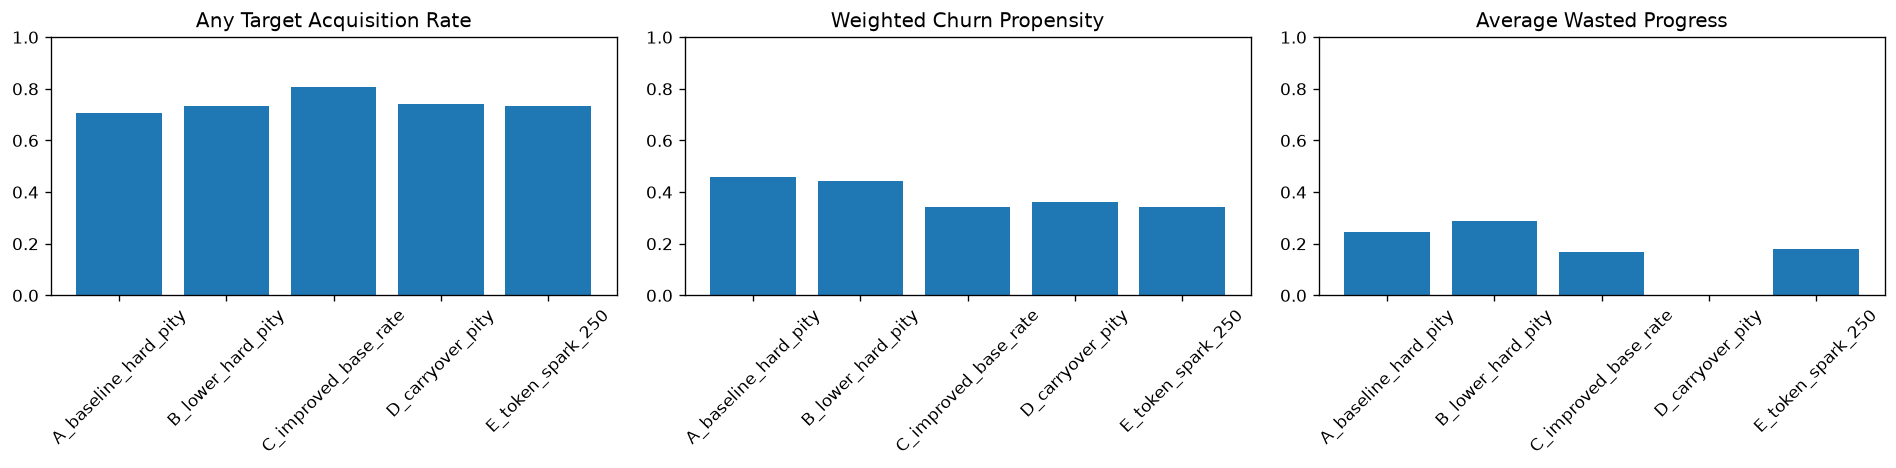

In [9]:
plot_df = summary_df[summary_df["weight_model"] == "equal_weight"].copy()

fig, axes = plt.subplots(1, 3, figsize=(16, 4), dpi=120)

axes[0].bar(plot_df["scenario"], plot_df["any_target_acquisition_rate"])
axes[0].set_title("Any Target Acquisition Rate")
axes[0].tick_params(axis="x", rotation=45)
axes[0].set_ylim(0, 1)

axes[1].bar(plot_df["scenario"], plot_df["weighted_churn_propensity"])
axes[1].set_title("Weighted Churn Propensity")
axes[1].tick_params(axis="x", rotation=45)
axes[1].set_ylim(0, 1)

axes[2].bar(plot_df["scenario"], plot_df["avg_wasted_progress"])
axes[2].set_title("Average Wasted Progress")
axes[2].tick_params(axis="x", rotation=45)
axes[2].set_ylim(0, 1)

plt.tight_layout()
fig.savefig(DIAGRAMS_DIR / "scenario_policy_comparison.png", bbox_inches="tight")
plt.show()


## 10. Replication Summary and Confidence Intervals

The next cells run scenarios across independent replications and compute simple 95% confidence intervals from the replication-level summary distribution.

For the final report, avoid relying on a single run. Use these replication summaries instead.


In [10]:
def ci95(series: pd.Series) -> tuple[float, float]:
    mean_value = float(series.mean())

    if len(series) <= 1:
        return mean_value, mean_value

    standard_error = float(series.std(ddof=1) / np.sqrt(len(series)))
    margin = 1.96 * standard_error
    return mean_value - margin, mean_value + margin


def run_replications(
    scenario: Scenario,
    replications: int = DEFAULT_REPLICATIONS,
    players: int = DEFAULT_PLAYERS,
    banners: int = DEFAULT_BANNERS,
    copy_goal_model: str = DEFAULT_COPY_GOAL_MODEL,
) -> pd.DataFrame:
    runs = []

    for replication in range(replications):
        run = simulate_population(
            scenario,
            players=players,
            seed=42 + replication,
            banners=banners,
            copy_goal_model=copy_goal_model,
        )
        run["replication"] = replication + 1
        runs.append(run)

    return pd.concat(runs, ignore_index=True)


def summarize_replication_level(
    replication_output: pd.DataFrame,
    scenario: Scenario,
    weight_model: str,
) -> pd.DataFrame:
    rows = []

    for replication, df_rep in replication_output.groupby("replication"):
        row = summarize_results(df_rep, scenario.name, scenario, weight_model)
        row["replication"] = replication
        rows.append(row)

    return pd.DataFrame(rows)


replication_summary_rows = []

for scenario in scenarios:
    replication_output = run_replications(
        scenario,
        replications=10,
        players=2_000,
        banners=DEFAULT_BANNERS,
        copy_goal_model=DEFAULT_COPY_GOAL_MODEL,
    )

    for weight_model in SEGMENT_WEIGHT_MODELS:
        replication_summary_rows.append(
            summarize_replication_level(replication_output, scenario, weight_model)
        )

replication_summary_df = pd.concat(replication_summary_rows, ignore_index=True)
replication_summary_df.head()


,scenario,weight_model,base_rate,pity_threshold,carryover,token_threshold,any_target_acquisition_rate,copy_goal_completion_rate,avg_completed_goal_banners,avg_target_obtained_banners,...,pity_activation_rate,token_redemption_rate,avg_wasted_progress,avg_frustration_score,mean_churn_propensity,weighted_churn_propensity,observed_churn_rate,avg_dupe_utility,avg_dupe_gain,replication
0,A_baseline_hard_pity,equal_weight,0.008,330,False,0,0.7105,0.5055,1.1190,2.0390,...,0.0330,0.0,0.240161,0.456563,0.455638,0.455638,0.9480,0.457270,0.457270,1
1,A_baseline_hard_pity,equal_weight,0.008,330,False,0,0.7025,0.4885,1.0605,1.9680,...,0.0365,0.0,0.246119,0.463337,0.462209,0.462209,0.9565,0.449033,0.449033,2
2,A_baseline_hard_pity,equal_weight,0.008,330,False,0,0.7220,0.5210,1.1310,2.0685,...,0.0365,0.0,0.245207,0.457189,0.454294,0.454294,0.9535,0.458873,0.458873,3
3,A_baseline_hard_pity,equal_weight,0.008,330,False,0,0.6950,0.4855,1.1015,2.0410,...,0.0320,0.0,0.247072,0.464719,0.463691,0.463691,0.9530,0.447368,0.447368,4
4,A_baseline_hard_pity,equal_weight,0.008,330,False,0,0.7110,0.4960,1.0835,2.0145,...,0.0345,0.0,0.246552,0.460242,0.459247,0.459247,0.9555,0.453490,0.453490,5


In [11]:
metrics_for_ci = [
    "any_target_acquisition_rate",
    "copy_goal_completion_rate",
    "avg_total_pulls",
    "avg_wasted_progress",
    "avg_frustration_score",
    "mean_churn_propensity",
    "weighted_churn_propensity",
    "observed_churn_rate",
    "avg_dupe_utility",
]

confidence_rows = []

for (scenario_name, weight_model), group in replication_summary_df.groupby(["scenario", "weight_model"]):
    row = {
        "scenario": scenario_name,
        "weight_model": weight_model,
    }

    for metric in metrics_for_ci:
        low, high = ci95(group[metric])
        row[f"{metric}_mean"] = float(group[metric].mean())
        row[f"{metric}_ci_low"] = low
        row[f"{metric}_ci_high"] = high

    confidence_rows.append(row)

confidence_df = pd.DataFrame(confidence_rows)
confidence_df


,scenario,weight_model,any_target_acquisition_rate_mean,any_target_acquisition_rate_ci_low,any_target_acquisition_rate_ci_high,copy_goal_completion_rate_mean,copy_goal_completion_rate_ci_low,copy_goal_completion_rate_ci_high,avg_total_pulls_mean,avg_total_pulls_ci_low,...,mean_churn_propensity_ci_high,weighted_churn_propensity_mean,weighted_churn_propensity_ci_low,weighted_churn_propensity_ci_high,observed_churn_rate_mean,observed_churn_rate_ci_low,observed_churn_rate_ci_high,avg_dupe_utility_mean,avg_dupe_utility_ci_low,avg_dupe_utility_ci_high
0,A_baseline_hard_pity,equal_weight,0.71290,0.707153,0.718647,0.50355,0.496280,0.510820,467.12735,460.825451,...,0.458676,0.455958,0.453240,0.458676,0.95345,0.951048,0.955852,0.457092,0.453737,0.460447
1,A_baseline_hard_pity,f2p_heavy,0.71290,0.707153,0.718647,0.50355,0.496280,0.510820,467.12735,460.825451,...,0.458676,0.574199,0.569815,0.578582,0.95345,0.951048,0.955852,0.457092,0.453737,0.460447
2,A_baseline_hard_pity,spender_focused,0.71290,0.707153,0.718647,0.50355,0.496280,0.510820,467.12735,460.825451,...,0.458676,0.437998,0.434189,0.441807,0.95345,0.951048,0.955852,0.457092,0.453737,0.460447
3,B_lower_hard_pity,equal_weight,0.72035,0.714732,0.725968,0.50965,0.502340,0.516960,486.07135,480.556725,...,0.453052,0.450606,0.448159,0.453052,0.94840,0.945870,0.950930,0.472244,0.469208,0.475281
4,B_lower_hard_pity,f2p_heavy,0.72035,0.714732,0.725968,0.50965,0.502340,0.516960,486.07135,480.556725,...,0.453052,0.577656,0.572011,0.583301,0.94840,0.945870,0.950930,0.472244,0.469208,0.475281
5,B_lower_hard_pity,spender_focused,0.72035,0.714732,0.725968,0.50965,0.502340,0.516960,486.07135,480.556725,...,0.453052,0.449166,0.445175,0.453158,0.94840,0.945870,0.950930,0.472244,0.469208,0.475281
6,C_improved_base_rate,equal_weight,0.81195,0.806680,0.817220,0.71270,0.708496,0.716904,574.33860,570.796550,...,0.341971,0.339678,0.337384,0.341971,0.84865,0.845165,0.852135,0.604278,0.601619,0.606938
7,C_improved_base_rate,f2p_heavy,0.81195,0.806680,0.817220,0.71270,0.708496,0.716904,574.33860,570.796550,...,0.341971,0.478362,0.473423,0.483301,0.84865,0.845165,0.852135,0.604278,0.601619,0.606938
8,C_improved_base_rate,spender_focused,0.81195,0.806680,0.817220,0.71270,0.708496,0.716904,574.33860,570.796550,...,0.341971,0.308417,0.304635,0.312199,0.84865,0.845165,0.852135,0.604278,0.601619,0.606938
9,D_carryover_pity,equal_weight,0.74075,0.736118,0.745382,0.57070,0.562702,0.578698,614.42410,607.826141,...,0.362733,0.360547,0.358360,0.362733,0.87730,0.873149,0.881451,0.482614,0.479369,0.485859


## 11. Sensitivity Analysis

This section tests whether the preferred policy changes under different assumptions:

- target rate,
- pity threshold,
- token threshold,
- copy-goal model,
- segment-weighting model,
- time horizon.


In [12]:
sensitivity_rows = []

# Base-rate and pity-threshold sensitivity.
for base_rate in SENSITIVITY_RATE_LEVELS:
    for pity_threshold in SENSITIVITY_PITY_LEVELS:
        sensitivity_scenario = Scenario(
            f"sensitivity_rate_{base_rate}_pity_{pity_threshold}",
            base_rate=base_rate,
            pity_threshold=pity_threshold,
        )

        data = simulate_population(
            sensitivity_scenario,
            players=2_000,
            seed=101,
            banners=DEFAULT_BANNERS,
            copy_goal_model=DEFAULT_COPY_GOAL_MODEL,
        )

        for weight_model in SEGMENT_WEIGHT_MODELS:
            row = summarize_results(data, sensitivity_scenario.name, sensitivity_scenario, weight_model)
            row["sensitivity_type"] = "rate_and_pity"
            row["copy_goal_model"] = DEFAULT_COPY_GOAL_MODEL
            row["banners"] = DEFAULT_BANNERS
            sensitivity_rows.append(row)


# Token threshold sensitivity.
for token_threshold in SENSITIVITY_TOKEN_LEVELS:
    sensitivity_scenario = Scenario(
        f"sensitivity_token_{token_threshold}",
        base_rate=0.008,
        pity_threshold=330,
        token_threshold=token_threshold,
        token_carryover=True,
    )

    data = simulate_population(
        sensitivity_scenario,
        players=2_000,
        seed=202,
        banners=DEFAULT_BANNERS,
        copy_goal_model=DEFAULT_COPY_GOAL_MODEL,
    )

    for weight_model in SEGMENT_WEIGHT_MODELS:
        row = summarize_results(data, sensitivity_scenario.name, sensitivity_scenario, weight_model)
        row["sensitivity_type"] = "token_threshold"
        row["copy_goal_model"] = DEFAULT_COPY_GOAL_MODEL
        row["banners"] = DEFAULT_BANNERS
        sensitivity_rows.append(row)


# Copy-goal model sensitivity.
for copy_goal_model in COPY_GOAL_MODELS:
    sensitivity_scenario = Scenario(
        f"sensitivity_copy_goal_{copy_goal_model}",
        base_rate=0.008,
        pity_threshold=330,
        carryover=True,
    )

    data = simulate_population(
        sensitivity_scenario,
        players=2_000,
        seed=303,
        banners=DEFAULT_BANNERS,
        copy_goal_model=copy_goal_model,
    )

    for weight_model in SEGMENT_WEIGHT_MODELS:
        row = summarize_results(data, sensitivity_scenario.name, sensitivity_scenario, weight_model)
        row["sensitivity_type"] = "copy_goal_model"
        row["copy_goal_model"] = copy_goal_model
        row["banners"] = DEFAULT_BANNERS
        sensitivity_rows.append(row)


# Time-horizon sensitivity.
for banner_count in SENSITIVITY_BANNER_LEVELS:
    sensitivity_scenario = Scenario(
        f"sensitivity_banners_{banner_count}",
        base_rate=0.008,
        pity_threshold=330,
        carryover=True,
    )

    data = simulate_population(
        sensitivity_scenario,
        players=2_000,
        seed=404,
        banners=banner_count,
        copy_goal_model=DEFAULT_COPY_GOAL_MODEL,
    )

    for weight_model in SEGMENT_WEIGHT_MODELS:
        row = summarize_results(data, sensitivity_scenario.name, sensitivity_scenario, weight_model)
        row["sensitivity_type"] = "time_horizon"
        row["copy_goal_model"] = DEFAULT_COPY_GOAL_MODEL
        row["banners"] = banner_count
        sensitivity_rows.append(row)


sensitivity_df = pd.DataFrame(sensitivity_rows)
sensitivity_df.head()


,scenario,weight_model,base_rate,pity_threshold,carryover,token_threshold,any_target_acquisition_rate,copy_goal_completion_rate,avg_completed_goal_banners,avg_target_obtained_banners,...,avg_wasted_progress,avg_frustration_score,mean_churn_propensity,weighted_churn_propensity,observed_churn_rate,avg_dupe_utility,avg_dupe_gain,sensitivity_type,copy_goal_model,banners
0,sensitivity_rate_0.008_pity_250,equal_weight,0.008,250,False,0,0.719,0.5125,1.0940,2.1035,...,0.297054,0.465938,0.454799,0.454799,0.9515,0.467632,0.467632,rate_and_pity,np_aware_mixed,8
1,sensitivity_rate_0.008_pity_250,f2p_heavy,0.008,250,False,0,0.719,0.5125,1.0940,2.1035,...,0.297054,0.465938,0.454799,0.588127,0.9515,0.467632,0.467632,rate_and_pity,np_aware_mixed,8
2,sensitivity_rate_0.008_pity_250,spender_focused,0.008,250,False,0,0.719,0.5125,1.0940,2.1035,...,0.297054,0.465938,0.454799,0.440203,0.9515,0.467632,0.467632,rate_and_pity,np_aware_mixed,8
3,sensitivity_rate_0.008_pity_330,equal_weight,0.008,330,False,0,0.699,0.4925,1.0755,1.9790,...,0.251507,0.464531,0.466012,0.466012,0.9640,0.444837,0.444837,rate_and_pity,np_aware_mixed,8
4,sensitivity_rate_0.008_pity_330,f2p_heavy,0.008,330,False,0,0.699,0.4925,1.0755,1.9790,...,0.251507,0.464531,0.466012,0.583697,0.9640,0.444837,0.444837,rate_and_pity,np_aware_mixed,8


## 12. Export Outputs

The notebook exports CSV files for direct use in the report:

- `scenario_summary.csv`
- `segment_summary.csv`
- `scenario_confidence_intervals.csv`
- `scenario_sensitivity.csv`
- `verification_checks.csv`

In [ ]:
summary_df.to_csv(OUTPUT_DIR / "scenario_summary.csv", index=False)
segment_df.to_csv(OUTPUT_DIR / "segment_summary.csv", index=False)
confidence_df.to_csv(OUTPUT_DIR / "scenario_confidence_intervals.csv", index=False)
sensitivity_df.to_csv(OUTPUT_DIR / "scenario_sensitivity.csv", index=False)
verification_df.to_csv(OUTPUT_DIR / "verification_checks.csv", index=False)

print("Exported simulation outputs to:", OUTPUT_DIR.resolve())

Exported updated simulation outputs to: C:\Users\Christian\Downloads\CSS142P-FInal-Project\Outputs
